# ResNet-18 Iteration 06 — Patient Metadata Fusion

## Objective
Iteration 05 (Dropout + AdamW + TTA + L1) is the strongest ResNet-18 configuration with Test F2 0.6341 and AUC 0.8978. EfficientNet-B0 Iter 05 demonstrated that fusing patient metadata (age, sex, body localisation) with image features pushed AUC from 0.9077 to 0.9199. This iteration applies the same metadata fusion strategy to ResNet-18 using a new `ResNet18WithMetadata` model class, keeping all other hyperparameters from Iter 05 identical to isolate the effect of the metadata signal. TTA is applied at inference for a direct comparison with Iter 05.

## Architecture Changes

| Component | Iter 05 (L1 + Dropout + TTA) | Iter 06 (Metadata Fusion) |
|---|---|---|
| Model | `get_resnet` (ResNet-18) | **`ResNet18WithMetadata`** |
| Image features | 512-dim → FC | 512-dim → fusion head |
| Patient metadata | None | **age + sex + localization (dim=17)** |
| Metadata encoder | None | **Linear(17, 32) → ReLU** |
| Fusion | None | **cat(512, 32) → Dropout → Linear(544, 1)** |
| Dropout | 0.4 | 0.4 |
| L1 lambda | 1e-3 | 1e-3 |
| pos_weight | 5.0 | 5.0 |
| LR — backbone | 1e-4 (uniform) | 1e-4 |
| LR — head | 1e-4 (uniform) | **1e-3** |
| Weight decay | 1e-4 | 1e-4 |
| Scheduler | CosineAnnealingLR | CosineAnnealingLR |
| Epochs | 25 | 30 |
| TTA at inference | Yes (8×) | Yes (8×) |

## Hypothesis
Patient metadata provides discriminative signal that image features alone cannot capture — age (older patients carry higher melanoma risk), sex, and body site all correlate with melanoma prevalence. Concatenating a 32-dim metadata encoding with the 512-dim ResNet-18 image features before the classifier should allow borderline predictions to be adjusted using patient context, improving both AUC and F2 over Iter 05.

## Import libraries, set seed, and choose device

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from PIL import Image
from sklearn.metrics import fbeta_score

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000DatasetWithMetadata
from src.data.transform import get_augmented_train_transforms, get_eval_transforms
from src.models.resnet import ResNet18WithMetadata
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
from src.utils import seed_everything, seed_worker

import pandas as pd

g = seed_everything(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
METADATA_PATH      = str(ROOT / 'data_new/raw/HAM10000_metadata')
TEST_METADATA_PATH = str(ROOT / 'data_new/raw/ISIC2018_Task3_Test_GroundTruth.csv')

train_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    worker_init_fn=seed_worker,
    generator=g,
)

val_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

test_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus/num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Positive weight: tensor([8.1117], device='cuda:0')
Train: 7991 | Val: 2024 | Test: 1511


## Model Definition

In [3]:
METADATA_DIM = 17
DROPOUT      = 0

model = ResNet18WithMetadata(
    metadata_dim=METADATA_DIM,
    num_classes=1,
    freeze_backbone=False,
    dropout=DROPOUT,
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW([
    {'params': model.backbone.parameters(),      'lr': 1e-4},
    {'params': model.meta_encoder.parameters(),  'lr': 1e-3},
    {'params': model.head.parameters(),          'lr': 1e-3},
], weight_decay=1e-4)

num_epochs = 60
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {DROPOUT}')

Trainable params: 11,177,633 / 11,177,633
L1 lambda: 0.001 | L2 lambda: 0.0 | Dropout: 0


## Training Loop

In [4]:
best_val_auc = 0.0
best_epoch   = 0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA, use_metadata=True,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device, use_metadata=True)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), ROOT / 'models/06.resnet_metadata_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

print(f'Best checkpoint: epoch {best_epoch} | Val AUC: {best_val_auc:.4f}')

Epoch [1/60]
  Train | Loss: 0.8995, Bal Acc: 0.7485, Recall: 0.7970, F2: 0.5511, AUC: 0.8269
  Val   | Loss: 0.7953, Bal Acc: 0.7856, Recall: 0.9280, F2: 0.6080, AUC: 0.8728
  -> Saved best model (val AUC: 0.8728)


Epoch [2/60]
  Train | Loss: 0.8311, Bal Acc: 0.7667, Recall: 0.8096, F2: 0.5742, AUC: 0.8536
  Val   | Loss: 0.8262, Bal Acc: 0.7705, Recall: 0.7754, F2: 0.5918, AUC: 0.8643


Epoch [3/60]
  Train | Loss: 0.8400, Bal Acc: 0.7842, Recall: 0.8107, F2: 0.5982, AUC: 0.8571
  Val   | Loss: 0.8080, Bal Acc: 0.7886, Recall: 0.7585, F2: 0.6185, AUC: 0.8808
  -> Saved best model (val AUC: 0.8808)


Epoch [4/60]
  Train | Loss: 0.8199, Bal Acc: 0.7859, Recall: 0.8096, F2: 0.6007, AUC: 0.8616
  Val   | Loss: 0.8487, Bal Acc: 0.7734, Recall: 0.9237, F2: 0.5937, AUC: 0.8733


Epoch [5/60]
  Train | Loss: 0.8139, Bal Acc: 0.7856, Recall: 0.8164, F2: 0.5999, AUC: 0.8638
  Val   | Loss: 0.7895, Bal Acc: 0.7957, Recall: 0.8263, F2: 0.6254, AUC: 0.8859
  -> Saved best model (val AUC: 0.8859)


...

Epoch [56/60]
  Train | Loss: 0.6446, Bal Acc: 0.8369, Recall: 0.8928, F2: 0.6693, AUC: 0.9160
  Val   | Loss: 0.7167, Bal Acc: 0.8173, Recall: 0.9025, F2: 0.6510, AUC: 0.9019


Epoch [57/60]
  Train | Loss: 0.6493, Bal Acc: 0.8304, Recall: 0.8757, F2: 0.6615, AUC: 0.9138
  Val   | Loss: 0.7174, Bal Acc: 0.8132, Recall: 0.9110, F2: 0.6445, AUC: 0.9018


Epoch [58/60]
  Train | Loss: 0.6513, Bal Acc: 0.8353, Recall: 0.8860, F2: 0.6679, AUC: 0.9134
  Val   | Loss: 0.7172, Bal Acc: 0.8115, Recall: 0.9025, F2: 0.6427, AUC: 0.9016


Epoch [59/60]
  Train | Loss: 0.6477, Bal Acc: 0.8341, Recall: 0.8860, F2: 0.6659, AUC: 0.9127
  Val   | Loss: 0.7166, Bal Acc: 0.8124, Recall: 0.8983, F2: 0.6444, AUC: 0.9020


Epoch [60/60]
  Train | Loss: 0.6234, Bal Acc: 0.8447, Recall: 0.9019, F2: 0.6806, AUC: 0.9200
  Val   | Loss: 0.7226, Bal Acc: 0.8084, Recall: 0.9110, F2: 0.6380, AUC: 0.9017
Best checkpoint: epoch 46 | Val AUC: 0.9023


## Plot Train and Validation Curves

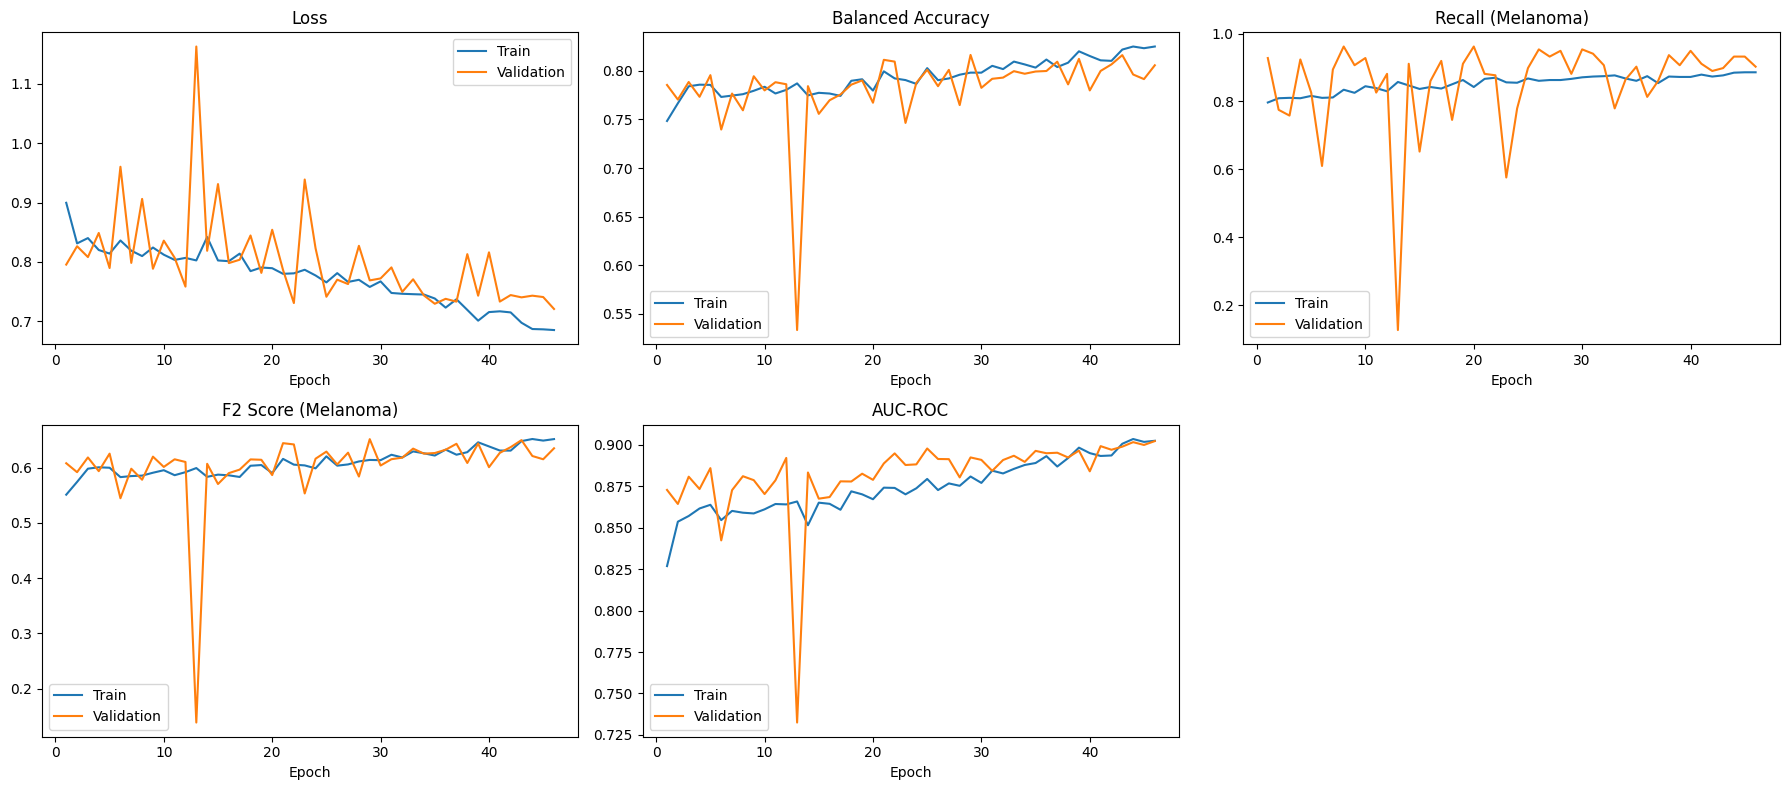

In [5]:
plot_training_curves(train_history, val_history, best_epoch=best_epoch)

## Threshold Tuning (Best Val F2)

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

model.load_state_dict(torch.load(str(ROOT / 'models/06.resnet_metadata_best.pth'), map_location=device))
model.eval()

# Re-load val dataset without transform for TTA
val_dataset_raw = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=None,
)

def _base(extra=None):
    ops = [transforms.Resize((224, 224))]
    if extra:
        ops += extra
    ops += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    return transforms.Compose(ops)

tta_transforms = [
    _base(),                                                          # 1. identity
    _base([transforms.RandomHorizontalFlip(p=1.0)]),                  # 2. H-flip
    _base([transforms.RandomVerticalFlip(p=1.0)]),                    # 3. V-flip
    _base([transforms.RandomHorizontalFlip(p=1.0),
           transforms.RandomVerticalFlip(p=1.0)]),                    # 4. HV-flip
    _base([transforms.RandomRotation(degrees=(90, 90))]),             # 5. rotate 90
    _base([transforms.RandomRotation(degrees=(180, 180))]),           # 6. rotate 180
    _base([transforms.RandomRotation(degrees=(270, 270))]),           # 7. rotate 270
    _base([transforms.RandomRotation(degrees=(45, 45))]),             # 8. rotate 45
]

def tta_predict(model, dataset, device, tta_transforms):
    all_probs, all_labels = [], []
    with torch.no_grad():
        for idx in range(len(dataset)):
            pil_img, metadata, label = dataset[idx]
            metadata = metadata.unsqueeze(0).to(device)
            preds = []
            for t in tta_transforms:
                tensor = t(pil_img).unsqueeze(0).to(device)
                prob = torch.sigmoid(model(tensor, metadata)).item()
                preds.append(prob)
            all_probs.append(np.mean(preds))
            all_labels.append(label)
    return np.array(all_probs), np.array(all_labels)

print('Running TTA on validation set...')
val_probs, val_labels = tta_predict(model, val_dataset_raw, device, tta_transforms)

thresholds = np.arange(0.01, 0.90, 0.01)
f2_scores  = [fbeta_score(val_labels, (val_probs >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Running TTA on validation set...
Best threshold: 0.64 | Val F2: 0.6642


## Test Set Evaluation

In [7]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

test_dataset_raw = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=None,
)

print('Running TTA on test set...')
test_probs, test_labels = tta_predict(model, test_dataset_raw, device, tta_transforms)
all_preds = (test_probs >= best_threshold).astype(int)

auc     = roc_auc_score(test_labels, test_probs)
bal_acc = balanced_accuracy_score(test_labels, all_preds)
f2      = fbeta_score(test_labels, all_preds, beta=2, pos_label=1, zero_division=0)

print(f'Threshold:          {best_threshold:.2f}')
print(f'AUC-ROC:            {auc:.4f}')
print(f'Balanced Accuracy:  {bal_acc:.4f}')
print(f'F2 Score:           {f2:.4f}')
print()
print(classification_report(test_labels, all_preds, target_names=['Non-Melanoma', 'Melanoma'], digits=4))

Running TTA on test set...
Threshold:          0.64
AUC-ROC:            0.9104
Balanced Accuracy:  0.8074
F2 Score:           0.6442

              precision    recall  f1-score   support

Non-Melanoma     0.9654    0.8545    0.9066      1340
    Melanoma     0.4000    0.7602    0.5242       171

    accuracy                         0.8438      1511
   macro avg     0.6827    0.8074    0.7154      1511
weighted avg     0.9014    0.8438    0.8633      1511

